In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import lineax as lx
import matplotlib.pyplot as plt

matrix_key, vector_key = jr.split(jr.PRNGKey(0))
matrix = jr.normal(matrix_key, (10, 10))
vector = jr.normal(vector_key, (10,))
operator = lx.MatrixLinearOperator(matrix)
solution = lx.linear_solve(operator, vector)

In [10]:
def f(x):
    return jnp.split(x, (2,8))[0]

jax.make_jaxpr(f)(jnp.ones((10,2)))

{ lambda ; a:f32[10,2]. let
    b:f32[2,2] _:f32[6,2] _:f32[2,2] = split[axis=0 sizes=(2, 6, 2)] a
  in (b,) }

In [12]:
f(jnp.ones((10,2)), (2,8))

TypeError: f() takes 1 positional argument but 2 were given

In [2]:
A = jnp.array([[1, 2], [3, 4]]).T
def transition_fn(x, t_old, t_new):
    return A@ x * (t_new - t_old)

# Linearize 

phi now should compute
$$ f(v) = J_x  v = A v $$ 


In [19]:
from probjax.utils.linear_operator import LinearOperator


def A(x):
    return x + 2*x[0]


T = LinearOperator(A, 2,2)

In [20]:
quadratic_form = T @ jnp.eye(2) @ T.T

In [21]:
jax.make_jaxpr(quadratic_form)(jnp.ones(2))

{ lambda a:f32[2,2]; b:f32[2]. let
    c:f32[] = reduce_sum[axes=(0,)] b
    d:f32[] = mul 2.0 c
    e:f32[1] = broadcast_in_dim[
      broadcast_dimensions=()
      shape=(1,)
      sharding=None
    ] d
    f:f32[2] = pad[padding_config=((0, 1, 0),)] e 0.0
    g:f32[2] = add_any b f
    h:f32[2] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=float32
    ] a g
    i:f32[1] = slice[limit_indices=(1,) start_indices=(0,) strides=None] h
    j:f32[] = squeeze[dimensions=(0,)] i
    k:f32[] = mul 2.0 j
    l:f32[2] = add h k
  in (l,) }

In [24]:
T.__jax_array__()

Array([[3., 2.],
       [0., 1.]], dtype=float32)

In [211]:
def f(x):
    return A@x


jax.make_jaxpr(f)(jnp.array([1, 2, 3]))

{ lambda a:f32[3,3]; b:i32[3]. let
    c:f32[3] = dot_general[
      dimension_numbers=(([1], [0]), ([], []))
      preferred_element_type=float32
    ] a b
  in (c,) }

In [189]:
jnp.linalg.solve(A, jnp.array([1, 2, 3]))

Array([1., 1., 1.], dtype=float32)

In [190]:
?jax.lax.custom_linear_solve

Signature:
jax.lax.custom_linear_solve(
    matvec,
    b,
    solve,
    transpose_solve=None,
    symmetric=False,
    has_aux=False,
)
Docstring:
Perform a matrix-free linear solve with implicitly defined gradients.

This function allows for overriding or defining gradients for a linear
solve directly via implicit differentiation at the solution, rather than by
differentiating *through* the solve operation. This can sometimes be much faster
or more numerically stable, or differentiating through the solve operation
may not even be implemented (e.g., if ``solve`` uses ``lax.while_loop``).

Required invariant::

    x = solve(matvec, b)  # solve the linear equation
    assert matvec(x) == b  # not checked

Args:
  matvec: linear function to invert. Must be differentiable.
  b: constant right handle side of the equation. May be any nested structure
    of arrays.
  solve: higher level function that solves for solution to the linear
    equation, i.e., ``solve(matvec, x) == x`` for all `

In [134]:
jnp.linalg.solve(A, jnp.array([1, 2, 3]))

TypeError: Error interpreting argument to <function solve at 0x7f204df3db20> as an abstract array. The problematic value is of type <class 'function'> and was passed to the function at path a.operator.
This typically means that a jit-wrapped function was called with a non-array argument, and this argument was not marked as static using the static_argnums or static_argnames parameters of jax.jit.

In [90]:
jax.scipy.sparse.linalg.cg(A, jnp.ones((3,3)))

(Array([[1.       , 0.5      , 0.3333333],
        [1.       , 0.5      , 0.3333333],
        [1.       , 0.5      , 0.3333333]], dtype=float32),
 None)

In [88]:
?jax.scipy.linalg.solve

Signature:
jax.scipy.linalg.solve(
    a: 'ArrayLike',
    b: 'ArrayLike',
    lower: 'bool' = False,
    overwrite_a: 'bool' = False,
    overwrite_b: 'bool' = False,
    debug: 'bool' = False,
    check_finite: 'bool' = True,
    assume_a: 'str' = 'gen',
) -> 'Array'
Docstring:
Solve a linear system of equations

JAX implementation of :func:`scipy.linalg.solve`.

This solves a (batched) linear system of equations ``a @ x = b`` for ``x``
given ``a`` and ``b``.

Args:
  a: array of shape ``(..., N, N)``.
  b: array of shape ``(..., N)`` or ``(..., N, M)``
  lower: Referenced only if ``assume_a != 'gen'``. If True, only use the lower
    triangle of the input, If False (default), only use the upper triangle.
  assume_a: specify what properties of ``a`` can be assumed. Options are:

    - ``"gen"``: generic matrix (default)
    - ``"sym"``: symmetric matrix
    - ``"her"``: hermitian matrix
    - ``"pos"``: positive-definite matrix

  overwrite_a: unused by JAX
  overwrite_b: unused by J

In [79]:


jax.scipy.linalg.tri

{'__name__': 'jax.scipy.linalg',
 '__doc__': None,
 '__package__': 'jax.scipy',
 '__loader__': <_frozen_importlib_external.SourceFileLoader at 0x7f2004123b00>,
 '__spec__': ModuleSpec(name='jax.scipy.linalg', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7f2004123b00>, origin='/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/jax/scipy/linalg.py'),
 '__file__': '/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/jax/scipy/linalg.py',
 '__cached__': '/root/miniconda3/envs/probjax_new/lib/python3.12/site-packages/jax/scipy/__pycache__/linalg.cpython-312.pyc',
 '__builtins__': {'__name__': 'builtins',
  '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjec

In [74]:
jax.scipy.sparse.linalg.cg(A, jnp.array([1, 2, 3]))[0]

TypeError: linear operator must be either a function or ndarray: DiagonalMatrix(diag=Array([1, 2, 3], dtype=int32))

In [15]:
_transition_fn = lambda x: transition_fn(x, 0., 1.)

out, phi = jax.linearize(_transition_fn, jnp.ones(2))

In [16]:
phi(jnp.ones(2))

Array([4., 6.], dtype=float32)

In [17]:
_phi_T = jax.linear_transpose(phi, jnp.ones(2))
phi_T = lambda x: _phi_T(x)[0]

In [18]:
phi_T(jnp.ones(2))

Array([3., 7.], dtype=float32)

In [19]:
A.T@jnp.ones(2)

Array([3., 7.], dtype=float32)

In [22]:
C = jnp.eye(2)


C2 = jax.vmap(phi)(C)
C3 = jax.vmap(phi_T)(C2)
C3

Array([[ 5., 11.],
       [11., 25.]], dtype=float32)

In [24]:
J = jax.jacobian(transition_fn)(jnp.ones(2), 1., 0.)
J @ (J@C).T

Array([[10., 14.],
       [14., 20.]], dtype=float32)

In [59]:
from typing import Callable

from jax.typing import ArrayLike


class LinearOperator:
    def __init__(self, A: ArrayLike | Callable):
        self.A = A

    @property
    def T(self):
        if callable(self.A):
            def adjoint(x):
                A_T = jax.linear_transpose(self.A)
                return A_T(x)[0]
            return LinearOperator(adjoint)
        else:
            return LinearOperator(self.A.T)

    def __matmul__(self, x):
        if callable(self.A):
            dims = len(x.shape)
            _f = self.A
            for _ in range(dims - 1):
                _f = jax.vmap(_f)
            return _f(x)
        else:
            return self.A @ x

    def __rmatmul__(self, x):
        tranposed_operator = self.T
        return tranposed_operator @ x

    def __mul__(self, scale):
        scale = jnp.asarray(scale)
        if callable(self.A):
            if scale.ndim == 0 or (scale.ndim == 1 and scale.shape[0] == 1):
                def new_operator(x):
                    return (self @ x) * scale
                return LinearOperator(new_operator)
            elif scale.ndim == 1:
                def new_operator(x):
                    out = self @ x
                    assert out.shape == scale.shape
                    return out * scale
                return LinearOperator(new_operator)
            else:
                raise ValueError(f"Invalid scale shape {scale.shape}")
        else:
            return LinearOperator(self.A * scale)

    def __add__(self, other):
        A_other = other.A if isinstance(other, LinearOperator) else other
        if callable(self.A) and callable(A_other):
            def new_operator(x):
                return self @ x + other @ x
            return LinearOperator(new_operator)
        elif callable(self.A):
            def new_operator(x):
                return self @ x + other
            return LinearOperator(new_operator)
        elif callable(A_other):
            def new_operator(x):
                return self @ x + A_other @ x
            return LinearOperator(new_operator)
        else:
            return LinearOperator(self.A + A_other)

    def __sub__(self, other):
        return self + (-1) * other

    def __neg__(self):
        return -1 * self

    def __call__(self, x):
        return self @ x

    def __repr__(self):
        return f"LinearOperator({self.A})"

    def __str__(self):
        return repr(self)

    def __jaxarray__(self):
        if callable(self.A):
            I


In [60]:
L = LinearOperator(phi)

L

In [61]:
L  + jnp.eye(2)

In [109]:
J = jax.jacfwd(f)(jnp.ones(2))

In [110]:
y = jnp.ones(2)*0.5


J @ y

Array([1.5, 1.5], dtype=float32)

In [158]:
def f(x):
    return jnp.sum(x + (A@x)**2) + jnp.sum(jnp.exp(x))

x0  = jnp.ones(2)
out, linearized = jax.linearize(f, x0)

In [159]:
from jax.experimental.jet import jet

In [163]:
vs = jnp.ones((2,))
x0 = jnp.ones((2,))
zeros = jnp.zeros((2,))
ones = jnp.ones((2,))


f0, *dfs =  jet(f, (x0,), ((ones,) + (zeros,)*5,))

f0,dfs

(Array(65.436455, dtype=float32),
 [[Array(123.43634, dtype=float32),
   Array(121.43634, dtype=float32),
   Array(5.436555, dtype=float32),
   Array(5.436552, dtype=float32),
   Array(5.436549, dtype=float32),
   Array(5.436547, dtype=float32)]])

In [161]:
jax.jacobian(f)(x0)@h0

Array(123.43657, dtype=float32)

In [162]:
(h0@jax.hessian(f)(x0)@h0)

Array(121.436554, dtype=float32)

In [138]:
h0.T@jax.hessian(f)(h0)@h0 / 2

Array(58., dtype=float32)

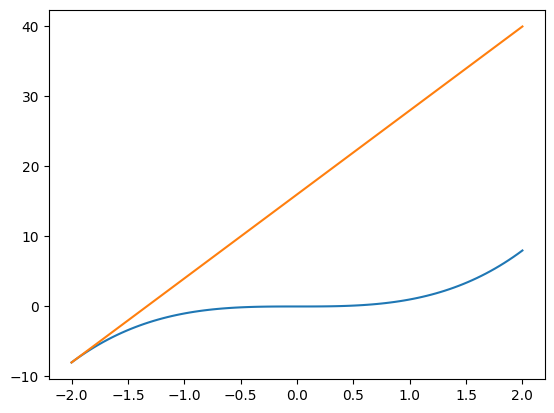

In [221]:
ts = jnp.linspace(-2, 2, 100)

plt.plot(ts, f(ts))
plt.plot(ts, out + jax.vmap(linearized)(ts - x0))


In [77]:
?jax.linear_transpose

Signature: jax.linear_transpose(fun: 'Callable', *primals, reduce_axes=()) -> 'Callable'
Docstring:
Transpose a function that is promised to be linear.

For linear functions, this transformation is equivalent to :py:func:`vjp`, but
avoids the overhead of computing the forward pass.

The outputs of the transposed function will always have the exact same dtypes
as ``primals``, even if some values are truncated (e.g., from complex to
float, or from float64 to float32). To avoid truncation, use dtypes in
``primals`` that match the full range of desired outputs from the transposed
function. Integer dtypes are not supported.

Args:
  fun: the linear function to be transposed.
  *primals: a positional argument tuple of arrays, scalars, or (nested)
    standard Python containers (tuples, lists, dicts, namedtuples, i.e.,
    pytrees) of those types used for evaluating the shape/dtype of
    ``fun(*primals)``. These arguments may be real scalars/ndarrays, but that
    is not required: only the `

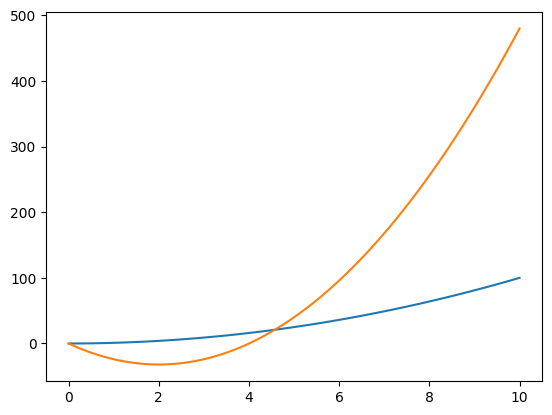

In [75]:
plt.plot(jnp.linspace(0, 10, 100), f(jnp.linspace(0, 10, 100)))
plt.plot(jnp.linspace(0, 10, 100), jax.vmap(linearized)(jnp.linspace(0, 10, 100)) * (jnp.linspace(0, 10, 100)-4.))

In [51]:
m = lx.JacobianLinearOperator(f, jnp.ones((1,))*2)

In [57]:
jax.tree_flatten(m)

/tmp/ipykernel_13160/3852874817.py:1: DeprecationWarning: jax.tree_flatten is deprecated: use jax.tree.flatten (jax v0.4.25 or newer) or jax.tree_util.tree_flatten (any JAX version).
  jax.tree_flatten(m)


([{ lambda ; a:f32[1]. let b:f32[1] = integer_pow[y=2] a in (b,) },
  Array([2.], dtype=float32)],
 PyTreeDef(CustomNode(JacobianLinearOperator[('fn', 'x', 'args', 'jac'), ('tags',), (frozenset(),)], [CustomNode(_ClosureConvert[('jaxpr', 'consts'), ('in_dynamic_struct', 'out_dynamic_struct', 'in_static', 'out_static'), (([ShapeDtypeStruct(shape=(1,), dtype=float32)], PyTreeDef(((*, None), {}))), ([ShapeDtypeStruct(shape=(1,), dtype=float32)], PyTreeDef((*, None))), ([], PyTreeDef(((None, None), {}))), ([], PyTreeDef((None, None))))], [*, []]), *, None, None])))

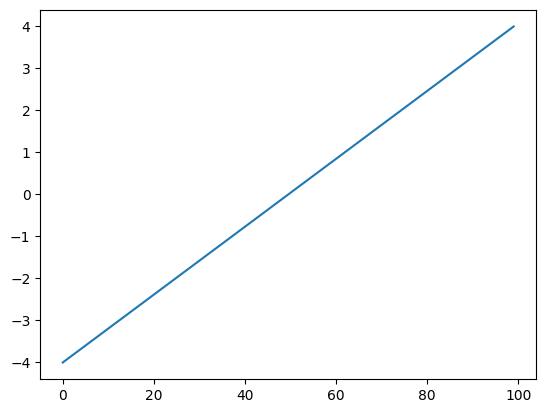

In [52]:
xs = jnp.linspace(-1, 1, 100)

plt.plot(jax.vmap(m.mv)(xs[:, None])[:,0])

In [2]:
diag_operator = lx.DiagonalLinearOperator(vector)

In [3]:
new_operator = operator@operator@operator

In [5]:
(new_operator @ diag_operator)

ComposedLinearOperator(
  operator1=ComposedLinearOperator(
    operator1=ComposedLinearOperator(
      operator1=MatrixLinearOperator(matrix=f32[10,10], tags=frozenset()),
      operator2=MatrixLinearOperator(matrix=f32[10,10], tags=frozenset())
    ),
    operator2=MatrixLinearOperator(matrix=f32[10,10], tags=frozenset())
  ),
  operator2=DiagonalLinearOperator(diagonal=f32[10])
)

In [7]:
lx.linear_solve

Signature:      
lx.linear_solve(
    operator: lineax._operator.AbstractLinearOperator,
    vector: jaxtyping.PyTree[typing.Union[jax.Array, numpy.ndarray, numpy.bool_, numpy.number, bool, int, float, complex]],
    solver: lineax._solve.AbstractLinearSolver = AutoLinearSolver(well_posed=True),
    *,
    options: Optional[dict[str, Any]] = None,
    state: jaxtyping.PyTree[typing.Any] = <object object at 0x7f048661bf80>,
    throw: bool = True,
) -> lineax._solution.Solution
Call signature:  lx.linear_solve(*args, **kwargs)
Type:            _JitWrapper
String form:    
_JitWrapper(
  fn='linear_solve',
  filter_warning=False,
  donate_first=False,
  donate_rest=False
)
File:            ~/miniconda3/envs/probjax_new/lib/python3.12/site-packages/lineax/_solve.py
Docstring:      
Solves a linear system.

Given an operator represented as a matrix $A$, and a vector $b$: if the operator is
square and nonsingular (so that the problem is well-posed), then this returns the
usual solution $x$ 

In [7]:
import jax
import lineax as lx

key = jax.random.PRNGKey(0)
y = jax.random.normal(key, (10,))

def quadratic_fn(y, args):
  return jax.numpy.sum((y - 1)**2)

gradient_fn = jax.grad(quadratic_fn)
hessian = lx.JacobianLinearOperator(gradient_fn, y, tags=lx.positive_semidefinite_tag)
solver = lx.CG(rtol=1e-6, atol=1e-6)
out = lx.linear_solve(hessian, gradient_fn(y, args=None), solver)
minimum = y - out.value

In [8]:
minimum

Array([0.99999994, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ],      dtype=float32)